In [1]:
# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_wine

In [2]:
# 2. Load Wine Dataset
wine = load_wine()
# Create a DataFrame from the dataset
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)

In [3]:
# For 'Simple' Linear Regression, we select one independent variable (X) and one target (y)
# 'flavanoids' and 'total_phenols' have a strong linear correlation
X = df[['flavanoids']]
y = df['total_phenols']

In [4]:
# 3. Basic Data Inspection
print("--- Data Head ---")
print(pd.concat([X, y], axis=1).head())

--- Data Head ---
   flavanoids  total_phenols
0        3.06           2.80
1        2.76           2.65
2        3.24           2.80
3        3.49           3.85
4        2.69           2.80


In [5]:
print("\n--- Data Info ---")
print(df.info())


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null   

In [6]:
# 4. Check for missing values
print("\nMissing Values in selected features:\n", pd.concat([X, y], axis=1).isnull().sum())


Missing Values in selected features:
 flavanoids       0
total_phenols    0
dtype: int64


In [7]:
# 5. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# 6. Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# 7. Build Simple Linear Regression Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [10]:
# 8. Predictions
y_pred = model.predict(X_test_scaled)

In [11]:
# 9. Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Intercept: {model.intercept_:.4f}")
print(f"Coefficient: {model.coef_[0]:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")


--- Model Evaluation ---
Intercept: 2.2891
Coefficient: 0.5397
Mean Squared Error: 0.0426
R² Score: 0.8717


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


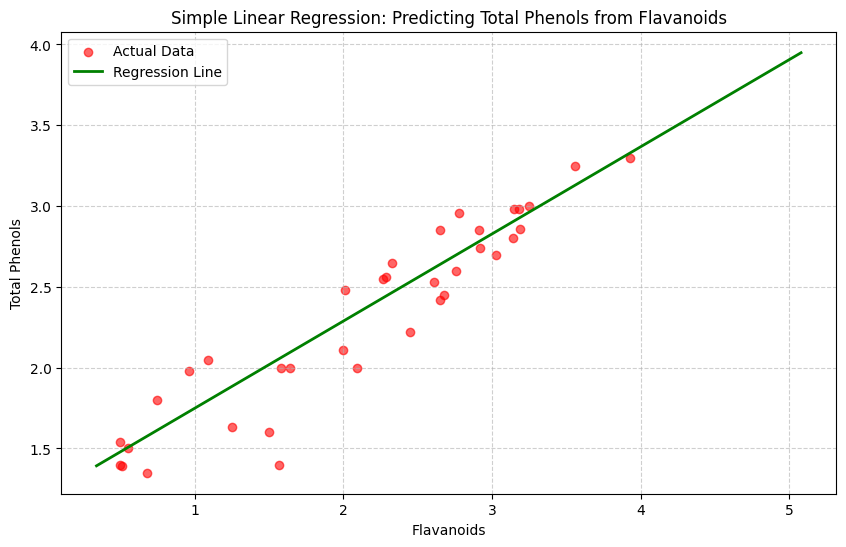

In [15]:
# 10. Visualization: Regression Line
plt.figure(figsize=(10, 6))
# Plot actual test data points
plt.scatter(X_test, y_test, color='red', alpha=0.6, label='Actual Data')

# Generate points to plot the continuous regression line
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_line_scaled = scaler.transform(X_line)
y_line_pred = model.predict(X_line_scaled)

plt.plot(X_line, y_line_pred, color='green', linewidth=2, label='Regression Line')
plt.xlabel('Flavanoids')
plt.ylabel('Total Phenols')
plt.title('Simple Linear Regression: Predicting Total Phenols from Flavanoids')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [16]:
# 11. Make a Single Prediction
# Let's predict the Total Phenols for a wine with Flavanoids = 3.0
sample_input = np.array([[3.0]])
sample_scaled = scaler.transform(sample_input)
predicted_value = model.predict(sample_scaled)[0]

print(f"\n--- Single Prediction ---")
print(f"For Flavanoids = 3.0, the Predicted Total Phenols is: {predicted_value:.2f}")


--- Single Prediction ---
For Flavanoids = 3.0, the Predicted Total Phenols is: 2.83


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
